# Tratamento incial de dados

## Preparando o ambiente

In [4]:
# instala as bibliotecas necessárias
!pip install pandas matplotlib seaborn scikit-learn
!pip install openpyxl


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:

# Biblioteca
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

## Lendo o arquivo Excel

In [6]:
# Carregando os dados - notar que aqui as abas estão nomeadas como 
# "PEDE2022", "PEDE2023" e "PEDE2024"
arquivo = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = pd.read_excel(arquivo, sheet_name="PEDE2022")
df_2023 = pd.read_excel(arquivo, sheet_name="PEDE2023")
df_2024 = pd.read_excel(arquivo, sheet_name="PEDE2024")

## Colunas - Transformando e padronizando

In [7]:
# Cria funcao "limpar_colunas" para limpar e padronizar os nomes das colunas
def limpar_colunas(df):
    df.columns = (
        df.columns.str.strip()  # Remove espaços em branco
        .str.lower()  # Converte para minúsculas
        .str.replace(" ", "_")  # Substitui espaços por underscores
        .str.replace("(", "")  # Remove parênteses
        .str.replace(")", "")  # Remove parênteses
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("utf-8") # remove acentos        
    )
    return df

In [8]:
# aplica a função de limpeza em cada DataFrame
df_2022 = limpar_colunas(df_2022)
df_2023 = limpar_colunas(df_2023)
df_2024 = limpar_colunas(df_2024)

In [9]:
# mostrando as primeiras linhas
print("Dados de 2022:")
print(df_2022.head())
print("\nInformações de 2022:")
print(df_2022.info())
print("\nDados de 2023:")
print(df_2023.head())
print("\nInformações de 2023:")
print(df_2023.info())
print("\nDados de 2024:")
print(df_2024.head())
print("\nInformações de 2024:")
print(df_2024.info())

Dados de 2022:
     ra  fase turma     nome  ano_nasc  idade_22  genero  ano_ingresso  \
0  RA-1     7     A  Aluno-1      2003        19  Menina          2016   
1  RA-2     7     A  Aluno-2      2005        17  Menina          2017   
2  RA-3     7     A  Aluno-3      2005        17  Menina          2016   
3  RA-4     7     A  Aluno-4      2005        17  Menino          2017   
4  RA-5     7     A  Aluno-5      2005        17  Menina          2016   

  instituicao_de_ensino  pedra_20  ... ingles indicado  atingiu_pv    ipv  \
0        Escola Pública  Ametista  ...    6.0      Sim         Não  7.278   
1          Rede Decisão  Ametista  ...    9.7      Não         Não  6.778   
2          Rede Decisão  Ametista  ...    6.9      Não         Não  7.556   
3          Rede Decisão  Ametista  ...    8.7      Não         Não  5.278   
4          Rede Decisão  Ametista  ...    5.7      Não         Não  7.389   

    ian               fase_ideal  defas  \
0   5.0  Fase 8 (Universitários)  

In [10]:
# identificando as colunas comuns entre os anos
colunas_comuns = set(df_2022.columns) & set(df_2023.columns) & set(df_2024.columns)
print("\nColunas comuns entre os anos:")
print(colunas_comuns)
print("\nNúmero de colunas comuns:", len(colunas_comuns))

# exibindo as colunas que não são comuns
colunas_2022 = set(df_2022.columns)
colunas_2023 = set(df_2023.columns)
colunas_2024 = set(df_2024.columns)
colunas_unicas_2022 = colunas_2022 - colunas_comuns
colunas_unicas_2023 = colunas_2023 - colunas_comuns
colunas_unicas_2024 = colunas_2024 - colunas_comuns
print("\nColunas únicas de 2022:", colunas_unicas_2022)
print("Colunas únicas de 2023:", colunas_unicas_2023)
print("Colunas únicas de 2024:", colunas_unicas_2024)


Colunas comuns entre os anos:
{'fase_ideal', 'atingiu_pv', 'destaque_ida', 'avaliador2', 'avaliador1', 'ieg', 'destaque_ipv', 'ips', 'inde_22', 'pedra_21', 'ian', 'ano_ingresso', 'rec_av1', 'ipv', 'rec_psicologia', 'indicado', 'ct', 'turma', 'genero', 'pedra_22', 'rec_av2', 'avaliador4', 'destaque_ieg', 'fase', 'instituicao_de_ensino', 'iaa', 'avaliador3', 'pedra_20', 'ida', 'cg', 'no_av', 'ra', 'cf'}

Número de colunas comuns: 33

Colunas únicas de 2022: {'matem', 'rec_av3', 'ano_nasc', 'rec_av4', 'idade_22', 'nome', 'ingles', 'portug', 'defas'}
Colunas únicas de 2023: {'rec_av3', 'data_de_nasc', 'mat', 'ing', 'pedra_2023', 'destaque_ipv.1', 'idade', 'ipp', 'defasagem', 'rec_av4', 'por', 'nome_anonimizado', 'inde_2023', 'pedra_23', 'inde_23'}
Colunas únicas de 2024: {'data_de_nasc', 'mat', 'inde_2024', 'ing', 'ipp', 'idade', 'ativo/_inativo', 'defasagem', 'pedra_2024', 'por', 'escola', 'avaliador5', 'nome_anonimizado', 'pedra_23', 'avaliador6', 'inde_23', 'ativo/_inativo.1'}


A coluna 'destaque_ipv.1' do 'df_2023' foi originada a partir de uma coluna duplicada durante a transformação dos dados para o ano de 20203, e ela contém os mesmos valores que a coluna 'destaque_ipv', então podemos considerar apenas uma delas para a análise, e a outra pode ser descartada para evitar redundância.

A mesma situação ocorre para a coluna 'ativo/_inativo.1' do 'df_2024', que também foi criada a partir de uma coluna duplicada durante a transformação dos dados para o ano de 2024, e contém os mesmos valores que a coluna 'ativo/_inativo', então podemos considerar apenas uma delas para a análise, e a outra pode ser descartada para evitar redundância.

In [11]:
# removendo a coluna 'destaque_ipv.1' do df_2023
df_2023.drop(columns=['destaque_ipv.1'], inplace=True)
# removendo a coluna 'ativo/_inativo.1' do df_2024
df_2024.drop(columns=['ativo/_inativo.1'], inplace=True)

As colunas de pedras estão no padrão 'pedra_aa' e 'pedra_aaaa', onde 'aa' representa os dois últimos dígitos do ano correspondente, ou seja, 'pedra_23' para o ano de 2023 e 'aaaa' rempresenta os quatro dígitos do ano correspondente, ou seja, 'pedra_2023' para o ano de 2023. 

No df_2023, a coluna 'pedra_23' está vazia, enquanto a coluna 'pedra_2023' contém os dados corretos. No df_2024, no lugar da coluna 'pedra_24' temos 'pedra_2024', que contém os dados corretos. 

Optaremos por manter o padrão 'pedra_aa' para as colunas de pedras, ou seja, 'pedra_23' para o ano de 2023 e 'pedra_24' para o ano de 2024, e descartaremos as colunas 'pedra_2023' para evitar redundância e manter a consistência nos nomes das colunas.

Para isso, vamos remover as colunas 'pedra_23' do df_2023, e manter as colunas 'pedra_2023' e 'pedra_2024' respectivamente. Em seguida, vamos renomear as colunas 'pedra_2023' para 'pedra_23' e 'pedra_2024' para 'pedra_24' para manter o padrão de nomenclatura consistente.

In [12]:
# removendo a coluna 'pedra_23' do df_2023
df_2023.drop(columns=['pedra_23'], inplace=True)
# renomeando a coluna 'pedra_2023' para 'pedra_23' no df_2023
df_2023.rename(columns={'pedra_2023': 'pedra_23'}, inplace=True)
# renomeando a coluna 'pedra_2024' para 'pedra_24' no df_2024
df_2024.rename(columns={'pedra_2024': 'pedra_24'}, inplace=True)
# removendo a coluna 'inde_23' do df_2023
df_2023.drop(columns=['inde_23'], inplace=True)
# renomeando a coluna 'inde_2023' para 'inde_23' no df_2023
df_2023.rename(columns={'inde_2023': 'inde_23'}, inplace=True)
# removendo a coluna 'inde_24' do df_2024
df_2024.rename(columns={'inde_2024': 'inde_24'}, inplace=True)

In [13]:
# convertendo o nome das colunas do df_2022 para o mesmo nome dos outros anos
df_2022.rename(
    columns={
        "nome": "nome_anonimizado",
        "portug": "por",
        "defas": "defasagem",
        "ano_nasc": "data_de_nasc",
        "idade_22": "idade",
        "ingles": "ing",
        "matem": "mat",
    },
    inplace=True,
)

# Adicionando as colunas 'rec_av3' e 'rec_av4' para o df_2024
df_2024['rec_av3'] = pd.NA
df_2024['rec_av4'] = pd.NA

# Adicionando a coluna "ano_base" para cada DataFrame
df_2022['ano_base'] = 2022
df_2023['ano_base'] = 2023
df_2024['ano_base'] = 2024


In [14]:
# identificando as colunas comuns entre os anos
colunas_comuns = set(df_2022.columns) & set(df_2023.columns) & set(df_2024.columns)
print("\nColunas comuns entre os anos:")
print(colunas_comuns)
print("\nNúmero de colunas comuns:", len(colunas_comuns))

# exibindo as colunas que não são comuns
colunas_2022 = set(df_2022.columns)
colunas_2023 = set(df_2023.columns)
colunas_2024 = set(df_2024.columns)
colunas_unicas_2022 = colunas_2022 - colunas_comuns
colunas_unicas_2023 = colunas_2023 - colunas_comuns
colunas_unicas_2024 = colunas_2024 - colunas_comuns
print("\nColunas únicas de 2022:", colunas_unicas_2022)
print("Colunas únicas de 2023:", colunas_unicas_2023)
print("Colunas únicas de 2024:", colunas_unicas_2024)


Colunas comuns entre os anos:
{'data_de_nasc', 'fase_ideal', 'atingiu_pv', 'destaque_ida', 'avaliador2', 'por', 'nome_anonimizado', 'avaliador1', 'ieg', 'destaque_ipv', 'ips', 'inde_22', 'pedra_21', 'ian', 'ano_ingresso', 'rec_av1', 'mat', 'ing', 'defasagem', 'ipv', 'rec_psicologia', 'indicado', 'ct', 'turma', 'genero', 'pedra_22', 'rec_av2', 'rec_av3', 'avaliador4', 'destaque_ieg', 'fase', 'idade', 'rec_av4', 'instituicao_de_ensino', 'ano_base', 'iaa', 'avaliador3', 'pedra_20', 'ida', 'cg', 'no_av', 'ra', 'cf'}

Número de colunas comuns: 43

Colunas únicas de 2022: set()
Colunas únicas de 2023: {'pedra_23', 'inde_23', 'ipp'}
Colunas únicas de 2024: {'inde_24', 'ipp', 'ativo/_inativo', 'escola', 'pedra_24', 'avaliador5', 'pedra_23', 'avaliador6', 'inde_23'}


## Unindo os dataframes

In [15]:
# Unindo os DataFrames em um único DataFrame
df_completo = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

In [16]:
# Exibindo as primeiras linhas de cada DataFrame para verificar os dados
print("Dados completos:")
print(df_completo.head())
print("\nInformações do DataFrame completo:")
print(df_completo.info())

Dados completos:
     ra fase turma nome_anonimizado data_de_nasc idade  genero  ano_ingresso  \
0  RA-1    7     A          Aluno-1         2003    19  Menina          2016   
1  RA-2    7     A          Aluno-2         2005    17  Menina          2017   
2  RA-3    7     A          Aluno-3         2005    17  Menina          2016   
3  RA-4    7     A          Aluno-4         2005    17  Menino          2017   
4  RA-5    7     A          Aluno-5         2005    17  Menina          2016   

  instituicao_de_ensino  pedra_20  ... ano_base inde_23  pedra_23  ipp  \
0        Escola Pública  Ametista  ...     2022     NaN       NaN  NaN   
1          Rede Decisão  Ametista  ...     2022     NaN       NaN  NaN   
2          Rede Decisão  Ametista  ...     2022     NaN       NaN  NaN   
3          Rede Decisão  Ametista  ...     2022     NaN       NaN  NaN   
4          Rede Decisão  Ametista  ...     2022     NaN       NaN  NaN   

   inde_24  pedra_24  avaliador5 avaliador6 escola ativo/

## Dados - Transformando e padronizando

a coluna 'ra' e 'nome_anonimizado' trazem basicamente o mesmo conteúdo, sendo RA-1 equivalente a Aluno-1, RA-2 equivalente a Aluno-2 e assim por diante. Dessa forma podemos remover a coluna 'nome_anonimizado' e manter apenas a coluna 'nome_anonimizado' para representar os alunos de forma anônima.

In [17]:
#removendo a coluna "nome_anonimizado"
df_completo.drop(columns=['nome_anonimizado'], inplace=True)

In [18]:
# exibindo os valores únicos de cada coluna para verificar a consistência dos dados
for coluna in df_completo.columns:
    print(f"Valores únicos da coluna '{coluna}':")
    print(df_completo[coluna].unique())
    print("\n")

Valores únicos da coluna 'ra':
['RA-1' 'RA-2' 'RA-3' ... 'RA-1659' 'RA-1660' 'RA-1661']


Valores únicos da coluna 'fase':
[7 6 5 4 3 2 1 0 'ALFA' 'FASE 1' 'FASE 2' 'FASE 3' 'FASE 4' 'FASE 5'
 'FASE 6' 'FASE 7' 'FASE 8' '1A' '1B' '1C' '1D' '1E' '1G' '1H' '1J' '1K'
 '1L' '1M' '1N' '1P' '1R' '2A' '2B' '2C' '2D' '2G' '2H' '2I' '2K' '2L'
 '2M' '2N' '2P' '2R' '2U' '3A' '3B' '3C' '3D' '3F' '3G' '3H' '3I' '3K'
 '3L' '3M' '3N' '3P' '3R' '3U' '4A' '4B' '4C' '4F' '4H' '4L' '4M' '4N'
 '4R' '5A' '5B' '5C' '5D' '5F' '5G' '5L' '5M' '5N' '6A' '6L' '7A' '7E'
 '8A' '8B' '8D' '8E' '8F' 9]


Valores únicos da coluna 'turma':
['A' 'D' 'B' 'C' 'F' 'K' 'L' 'H' 'P' 'E' 'G' 'I' 'M' 'N' 'J' 'Q' 'U' 'R'
 'O' 'S' 'T' 'V' 'Y' 'Z' 'ALFA A - G0/G1' 'ALFA B - G2/G3'
 'ALFA C - G0/G1' 'ALFA D - G2/G3' 'ALFA E - G2/G3' 'ALFA F - G0/G1'
 'ALFA G - G2/G3' 'ALFA H - G0/G1' 'ALFA I - G2/G3' 'ALFA J - G2/G3'
 'ALFA K - G0/G1' 'ALFA L - G2/G3' 'ALFA M - G0/G1' 'ALFA N - G2/G3'
 'ALFA O - G2/G3' 'ALFA Q - G2/G3' 'ALFA R - G0

Considarando que a coluna 'ra' é composta por um prefixo 'RA-' seguido de um número, podemos extrair este prefixo e manter apenas o número para facilitar a análise e comparação dos dados. Para isso, podemos utilizar a função de string do pandas para remover o prefixo 'RA-' e manter apenas os números correspondentes aos alunos.

In [19]:
# removendo o prefixo 'RA-' da coluna 'ra'
df_completo['ra'] = df_completo['ra'].str.replace('RA-', '', regex=False)
# convertendo a coluna 'ra' para inteiro, tratando erros de conversão   
df_completo['ra'] = pd.to_numeric(df_completo['ra'], errors='coerce').astype('Int64')

In [20]:
# Substitui 'ALFA' da coluna 'fase' por '0' antes de tentar extrair o número
df_completo['fase'] = df_completo['fase'].astype('string') # evita erros caso haja valores numéricos misturados com strings
df_completo['fase'] = df_completo['fase'].replace('ALFA', '0')
df_completo['fase'] = df_completo['fase'].str.extract('(\d+)').astype('Int64')

In [21]:
# convertendo a coluna 'turma' para string
df_completo['turma'] = df_completo['turma'].astype('string')
#convertendo o valor '9' da coluna 'turma' em 'N/A'
df_completo['turma'] = df_completo['turma'].replace('9', 'a definir')
# convertendo a turma de 'ALFA C - G0/G1' para 'C' e fazendo o mesmo para as outras turmas
df_completo['turma'] = df_completo['turma'].str.replace('ALFA ', '', regex=False)
df_completo['turma'] = df_completo['turma'].str.replace(' - G0/G1', '', regex=False)
df_completo['turma'] = df_completo['turma'].str.replace(' - G2/G3', '', regex=False)
# agora converte os valores '1A', '1B', '1C', etc. para apenas 'A', 'B', 'C', etc.
df_completo['turma'] = df_completo['turma'].str.replace(r'^\d+', '', regex=True)

In [22]:
# padronizando a coluna 'genero' para ter apenas 'masculino' e 'feminino'
df_completo['genero'] = df_completo['genero'].str.lower().str.strip()
df_completo['genero'] = df_completo['genero'].replace({'menino': 'masculino', 'menina': 'feminino'})

In [23]:
# padronizando as colunas das pedras de 'pedra_20' a 'pedra_24'
# remove acentos e normaliza os nomes das colunas de pedra
def padronizar_pedra(coluna):
    coluna = coluna.str.lower().str.strip()
    coluna = coluna.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
    return coluna
for i in range(20, 25):
    df_completo[f'pedra_{i}'] = padronizar_pedra(df_completo[f'pedra_{i}'])
# converte converte o valor 'incluir' em nulo
for i in range(20, 25):
    df_completo[f'pedra_{i}'] = df_completo[f'pedra_{i}'].replace('incluir', pd.NA)

In [24]:
# convertendo a data de narcimento que contem apenas o ano para o formato "01/01/AAAA" para manter a consistência com os outros anos
df_completo['data_de_nasc'] = df_completo['data_de_nasc'].apply(lambda x: f"01/01/{x}" if isinstance(x, (int, float)) else x)   
# convertendo a coluna 'data_de_nasc' do formato timestamp para datetime no formato "DD/MM/AAAA", tratando erros com 'coerce' para evitar problemas de conversão
df_completo['data_de_nasc'] = pd.to_datetime(df_completo['data_de_nasc'], errors='coerce').dt.strftime('%d/%m/%Y')


In [25]:
def limpar_idade(valor):
    # Se for um objeto de data, pegamos apenas o dia
    if isinstance(valor, datetime.datetime):
        return valor.day
    # Se for um número (ou string de número), convertemos para inteiro
    try:
        return int(float(valor))
    except:
        return None # Caso haja algum valor bizarro que não seja data nem número

# Aplicando a função na coluna
df_completo['idade'] = df_completo['idade'].apply(limpar_idade).astype('Int64')

In [26]:
# transforma os nulos de 'instituicao_de_ensino' em 'outros'
df_completo['instituicao_de_ensino'] = df_completo['instituicao_de_ensino'].fillna('outros')
# transforma os nulos de 'escola' em 'outros'
df_completo['escola'] = df_completo['escola'].fillna('outros')

In [27]:
# converte a coluna 'ano_ingresso' em inteiro, tratando erros com 'coerce' para evitar problemas de conversão
df_completo['ano_ingresso'] = pd.to_numeric(df_completo['ano_ingresso'], errors='coerce').astype('Int64')
df_completo['cg'] = pd.to_numeric(df_completo['cg'], errors='coerce').astype('Int64')
df_completo['cf'] = pd.to_numeric(df_completo['cf'], errors='coerce').astype('Int64')
df_completo['ct'] = pd.to_numeric(df_completo['ct'], errors='coerce').astype('Int64')
df_completo['no_av'] = pd.to_numeric(df_completo['no_av'], errors='coerce').astype('Int64')
df_completo['defasagem'] = pd.to_numeric(df_completo['defasagem'], errors='coerce').astype('Int64')
df_completo['ano_base'] = pd.to_numeric(df_completo['ano_base'], errors='coerce').astype('Int64')

# converte a coluna 'inde_22' em float, tratando erros com 'coerce' para evitar problemas de conversão
df_completo['inde_22'] = pd.to_numeric(df_completo['inde_22'], errors='coerce').astype('Float64')
df_completo['inde_23'] = pd.to_numeric(df_completo['inde_23'], errors='coerce').astype('Float64')
df_completo['iaa'] = pd.to_numeric(df_completo['iaa'], errors='coerce').astype('Float64')
df_completo['ieg'] = pd.to_numeric(df_completo['ieg'], errors='coerce').astype('Float64')
df_completo['ips'] = pd.to_numeric(df_completo['ips'], errors='coerce').astype('Float64')
df_completo['ida'] = pd.to_numeric(df_completo['ida'], errors='coerce').astype('Float64')
df_completo['mat'] = pd.to_numeric(df_completo['mat'], errors='coerce').astype('Float64')
df_completo['por'] = pd.to_numeric(df_completo['por'], errors='coerce').astype('Float64')
df_completo['ing'] = pd.to_numeric(df_completo['ing'], errors='coerce').astype('Float64')
df_completo['ipv'] = pd.to_numeric(df_completo['ipv'], errors='coerce').astype('Float64')
df_completo['ian'] = pd.to_numeric(df_completo['ian'], errors='coerce').astype('Float64')
df_completo['ipp'] = pd.to_numeric(df_completo['ipp'], errors='coerce').astype('Float64')

# converte a coluna 'rec_av1' em string, tratando erros com 'coerce' para evitar problemas de conversão
df_completo['rec_av1'] = df_completo['rec_av1'].astype('string')
df_completo['rec_av2'] = df_completo['rec_av2'].astype('string')
df_completo['rec_av3'] = df_completo['rec_av3'].astype('string')
df_completo['rec_av4'] = df_completo['rec_av4'].astype('string')
df_completo['rec_psicologia'] = df_completo['rec_psicologia'].astype('string')
df_completo['indicado'] = df_completo['indicado'].astype('string')
df_completo['atingiu_pv'] = df_completo['atingiu_pv'].astype('string')
df_completo['destaque_ieg'] = df_completo['destaque_ieg'].astype('string')
df_completo['destaque_ida'] = df_completo['destaque_ida'].astype('string')
df_completo['destaque_ipv'] = df_completo['destaque_ipv'].astype('string')

In [28]:
# converte o valor 'INCLUIR' da coluna 'inde_24' em nulo
df_completo['inde_24'] = df_completo['inde_24'].replace('INCLUIR', pd.NA)
# converte a coluna 'inde_24' em float, tratando erros com 'coerce' para evitar problemas de conversão
df_completo['inde_24'] = pd.to_numeric(df_completo['inde_24'], errors='coerce').astype('Float64')

In [29]:
# exibindo os valores únicos de cada coluna para verificar a consistência dos dados
for coluna in df_completo.columns:
    print(f"Valores únicos da coluna '{coluna}':")
    print(df_completo[coluna].unique())
    print("\n")

Valores únicos da coluna 'ra':
<IntegerArray>
[   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
 ...
 1652, 1653, 1654, 1655, 1656, 1657, 1658, 1659, 1660, 1661]
Length: 1661, dtype: Int64


Valores únicos da coluna 'fase':
<IntegerArray>
[7, 6, 5, 4, 3, 2, 1, 0, 8, 9]
Length: 10, dtype: Int64


Valores únicos da coluna 'turma':
<StringArray>
[        'A',         'D',         'B',         'C',         'F',         'K',
         'L',         'H',         'P',         'E',         'G',         'I',
         'M',         'N',         'J',         'Q',         'U',         'R',
         'O',         'S',         'T',         'V',         'Y',         'Z',
 'a definir']
Length: 25, dtype: string


Valores únicos da coluna 'data_de_nasc':
['01/01/2003' '01/01/2005' '01/01/2004' ... '03/06/2002' '28/06/2000'
 '29/01/2003']


Valores únicos da coluna 'idade':
<IntegerArray>
[19, 17, 18, 20, 21, 16, 15, 13, 14, 12, 11, 10, 9, 8, 7, 22, 26, 23, 24, 27,
 25]
Length: 21, dtype: Int64



In [30]:
# Exibindo as primeiras linhas de cada DataFrame para verificar os dados
print("Dados completos:")
print(df_completo.head())
print("\nInformações do DataFrame completo:")
print(df_completo.info())

Dados completos:
   ra  fase turma data_de_nasc  idade     genero  ano_ingresso  \
0   1     7     A   01/01/2003     19   feminino          2016   
1   2     7     A   01/01/2005     17   feminino          2017   
2   3     7     A   01/01/2005     17   feminino          2016   
3   4     7     A   01/01/2005     17  masculino          2017   
4   5     7     A   01/01/2005     17   feminino          2016   

  instituicao_de_ensino  pedra_20  pedra_21  ... ano_base  inde_23  pedra_23  \
0        Escola Pública  ametista  ametista  ...     2022     <NA>       NaN   
1          Rede Decisão  ametista  ametista  ...     2022     <NA>       NaN   
2          Rede Decisão  ametista  ametista  ...     2022     <NA>       NaN   
3          Rede Decisão  ametista  ametista  ...     2022     <NA>       NaN   
4          Rede Decisão  ametista  ametista  ...     2022     <NA>       NaN   

    ipp  inde_24  pedra_24 avaliador5 avaliador6  escola ativo/_inativo  
0  <NA>     <NA>       NaN     

In [31]:
# Verificando a porcentagem de valores nulos em cada coluna
df_completo.isnull().mean().sort_values(ascending=False)

avaliador6               0.998020
avaliador5               0.951155
rec_av4                  0.902310
pedra_20                 0.751155
rec_av1                  0.716172
atingiu_pv               0.716172
indicado                 0.716172
rec_av2                  0.716172
cg                       0.716172
destaque_ieg             0.716172
destaque_ida             0.716172
rec_psicologia           0.716172
rec_av3                  0.716172
ct                       0.716172
cf                       0.716172
destaque_ipv             0.716172
avaliador4               0.653135
inde_24                  0.652145
pedra_24                 0.652145
pedra_21                 0.649835
ing                      0.639934
ativo/_inativo           0.618482
inde_23                  0.465017
pedra_23                 0.465017
pedra_22                 0.362376
inde_22                  0.362376
ipp                      0.342574
avaliador3               0.328713
avaliador2               0.066997
avaliador1    

Apesar das colunas 'avaliador6', 'avaliador5', 'rec_av4' trazerem mais de 90% dos dados nulos, elas ainda contêm algumas informações relevantes para a análise, e por isso optamos por mantê-las no dataframe. Observa-se que quanto melhor a nota dos alunos, menor a quantidade de dados nulos nessas colunas, o que pode indicar que os alunos com melhor desempenho tendem a ter menos avaliações registradas. Portanto, mesmo com a presença de dados nulos, essas colunas ainda podem fornecer insights valiosos sobre o desempenho dos alunos e suas avaliações.

## Agrupando as colunas de acordo com o tipo de informação

Para organizar as 51 colunas de forma lógica, o ideal é agrupá-las por domínio de informação. Isso facilita tanto a criação de gráficos no Streamlit quanto a seleção de features para o seu modelo de Machine Learning.
1. Identificação e Demografia: Dados básicos do aluno.
2. Contexto Escolar e Status: Onde estuda e situação atual no programa.
3. Indicadores de Performance (Série "I"): Os índices fundamentais (IDA, IEG, IAA, etc.) que o desafio pede para analisar.
4. Histórico e Evolução Global: Resultados do INDE e a classificação por "Pedras" ao longo dos anos.
5. Componentes de Notas: Notas por disciplina e conceitos gerais.
6. Avaliações e Feedbacks: Colunas qualitativas (comentários de avaliadores e destaques).

In [32]:
# Definindo as listas de colunas por grupo
cols_identificacao = ['ra', 'genero', 'data_de_nasc', 'idade']

cols_contexto = ['escola', 'instituicao_de_ensino', 'ano_ingresso', 'fase', 'turma', 'fase_ideal', 'ativo/_inativo' , 'defasagem']

# Os indicadores principais que são o core do desafio
cols_indicadores_chave = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'atingiu_pv']

# Disciplinas e sub-conceitos
cols_notas_disciplinas = ['mat', 'por', 'ing', 'cg', 'cf', 'ct']

# Evolução temporal do índice global e classificação
cols_historico_global = [
    'pedra_20', 'pedra_21', 
    'pedra_22', 'inde_22', 
    'pedra_23', 'inde_23', 
    'pedra_24', 'inde_24'
]

# Dados de quem avaliou e textos de recomendação/destaque
cols_avaliacoes_feedback = [
    'no_av', 'avaliador1', 'rec_av1', 'avaliador2', 'rec_av2', 
    'avaliador3', 'rec_av3', 'avaliador4', 'rec_av4', 'avaliador5', 'avaliador6', 
    'rec_psicologia', 'indicado', 'destaque_ieg', 'destaque_ida', 'destaque_ipv'
]

cols_metadados = ['ano_base']

# Criando a nova ordem completa
nova_ordem = (cols_identificacao + cols_contexto + cols_indicadores_chave + 
              cols_notas_disciplinas + cols_historico_global + 
              cols_avaliacoes_feedback + cols_metadados)

# Reordenando o DataFrame
df_completo = df_completo[nova_ordem]

In [33]:
# Exibindo as primeiras linhas de cada DataFrame para verificar os dados
print("Dados completos:")
print(df_completo.head())
print("\nInformações do DataFrame completo:")
print(df_completo.info())

Dados completos:
   ra     genero data_de_nasc  idade  escola instituicao_de_ensino  \
0   1   feminino   01/01/2003     19  outros        Escola Pública   
1   2   feminino   01/01/2005     17  outros          Rede Decisão   
2   3   feminino   01/01/2005     17  outros          Rede Decisão   
3   4  masculino   01/01/2005     17  outros          Rede Decisão   
4   5   feminino   01/01/2005     17  outros          Rede Decisão   

   ano_ingresso  fase turma               fase_ideal  ...    avaliador4  \
0          2016     7     A  Fase 8 (Universitários)  ...  Avaliador-31   
1          2017     7     A           Fase 7 (3º EM)  ...  Avaliador-31   
2          2016     7     A           Fase 7 (3º EM)  ...  Avaliador-31   
3          2017     7     A           Fase 7 (3º EM)  ...  Avaliador-31   
4          2016     7     A           Fase 7 (3º EM)  ...  Avaliador-31   

                     rec_av4  avaliador5  avaliador6    rec_psicologia  \
0      Mantido na Fase atual         

# Explorando os dados

In [34]:
# aplicando o describe para explorar os grupamentos de colunas criados
print("Identificação:")
print(df_completo[cols_identificacao].describe(include='all'))
print("\nContexto:")
print(df_completo[cols_contexto].describe(include='all'))
print("\nIndicadores-chave:")
print(df_completo[cols_indicadores_chave].describe(include='all'))
print("\nNotas de disciplinas:")
print(df_completo[cols_notas_disciplinas].describe(include='all'))
print("\nHistórico global:")
print(df_completo[cols_historico_global].describe(include='all'))
print("\nAvaliações e feedback:")
print(df_completo[cols_avaliacoes_feedback].describe(include='all'))
print("\nMetadados:")
print(df_completo[cols_metadados].describe(include='all'))


Identificação:
                ra    genero data_de_nasc      idade
count       3030.0      3030         3030     3030.0
unique        <NA>         2         1401       <NA>
top           <NA>  feminino   01/01/2012       <NA>
freq          <NA>      1626          116       <NA>
mean    721.668647       NaN          NaN  12.527063
std     438.591959       NaN          NaN   3.299273
min            1.0       NaN          NaN        7.0
25%         364.25       NaN          NaN       10.0
50%          689.5       NaN          NaN       12.0
75%         1057.0       NaN          NaN       15.0
max         1661.0       NaN          NaN       27.0

Contexto:
        escola instituicao_de_ensino  ano_ingresso      fase turma  \
count     3030                  3030        3030.0    3030.0  3030   
unique      56                    12          <NA>      <NA>    25   
top     outros               Pública          <NA>      <NA>     A   
freq      1875                  1722          <NA>      <N

# Perguntas

## Pergunta 1: Adequação do nível (IAN)

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao
longo do ano?
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)

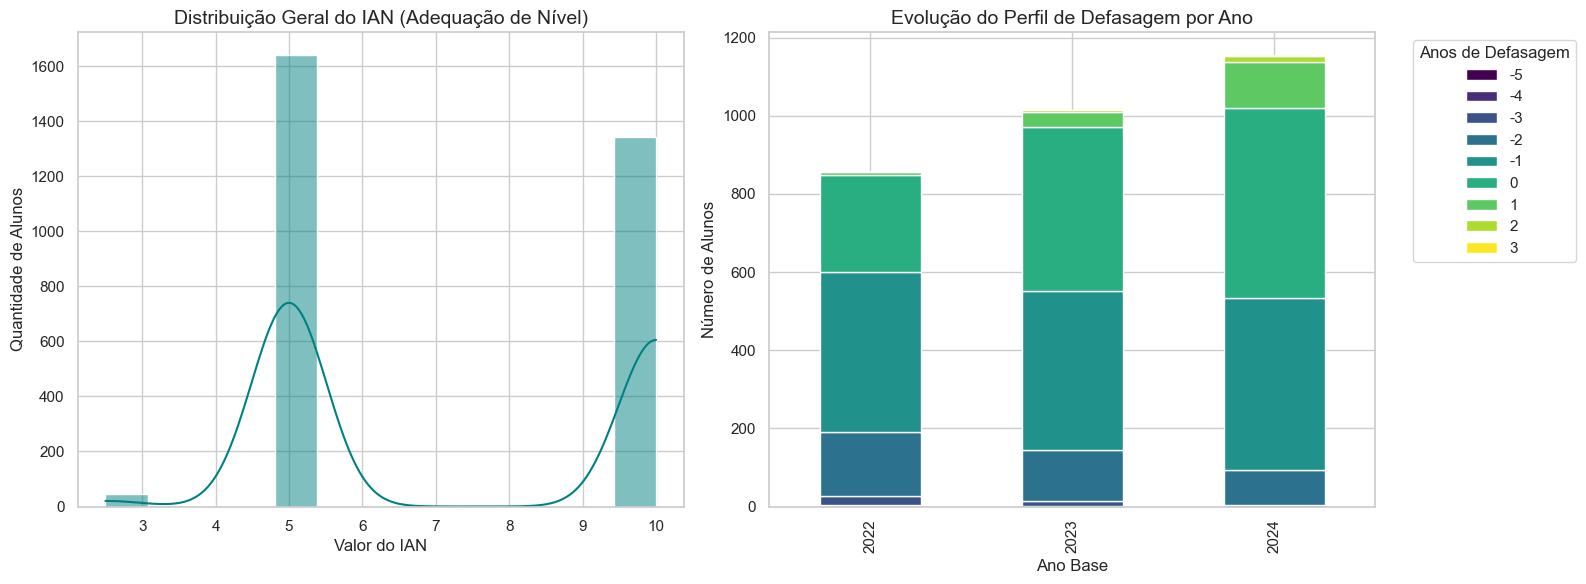

In [35]:
# Configuração de estilo para a apresentação gerencial
sns.set_theme(style="whitegrid")

# Criando uma figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Perfil Geral do IAN ---
sns.histplot(data=df_completo, x='ian', kde=True, color='teal', ax=ax1)
ax1.set_title('Distribuição Geral do IAN (Adequação de Nível)', fontsize=14)
ax1.set_xlabel('Valor do IAN', fontsize=12)
ax1.set_ylabel('Quantidade de Alunos', fontsize=12)

# --- GRÁFICO 2: Evolução da Defasagem (2022-2024) ---
# Agrupando os dados para contar alunos por ano e nível de defasagem
defasagem_count = df_completo.groupby(['ano_base', 'defasagem']).size().unstack(fill_value=0)

# Plotando barras empilhadas (stacked bar chart)
defasagem_count.plot(kind='bar', stacked=True, ax=ax2, colormap='viridis')
ax2.set_title('Evolução do Perfil de Defasagem por Ano', fontsize=14)
ax2.set_xlabel('Ano Base', fontsize=12)
ax2.set_ylabel('Número de Alunos', fontsize=12)
ax2.legend(title='Anos de Defasagem', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

A análise longitudinal revela que o programa atua diretamente na correção do atraso escolar. Entre 2022 e 2024, apesar do aumento do volume total de atendimentos, observamos uma redução proporcional contínua nos níveis de defasagem severa (menores que -1) e uma consolidação expressiva de alunos atingindo a fase ideal (nível 0).

## Pergunta 2: Desempenho acadêmico (IDA)

O desempenho acadêmico médio (IDA) está melhorando, estagnado ou
caindo ao longo das fases e anos?

C:\Users\edmar\AppData\Local\Temp\ipykernel_19088\3229824779.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


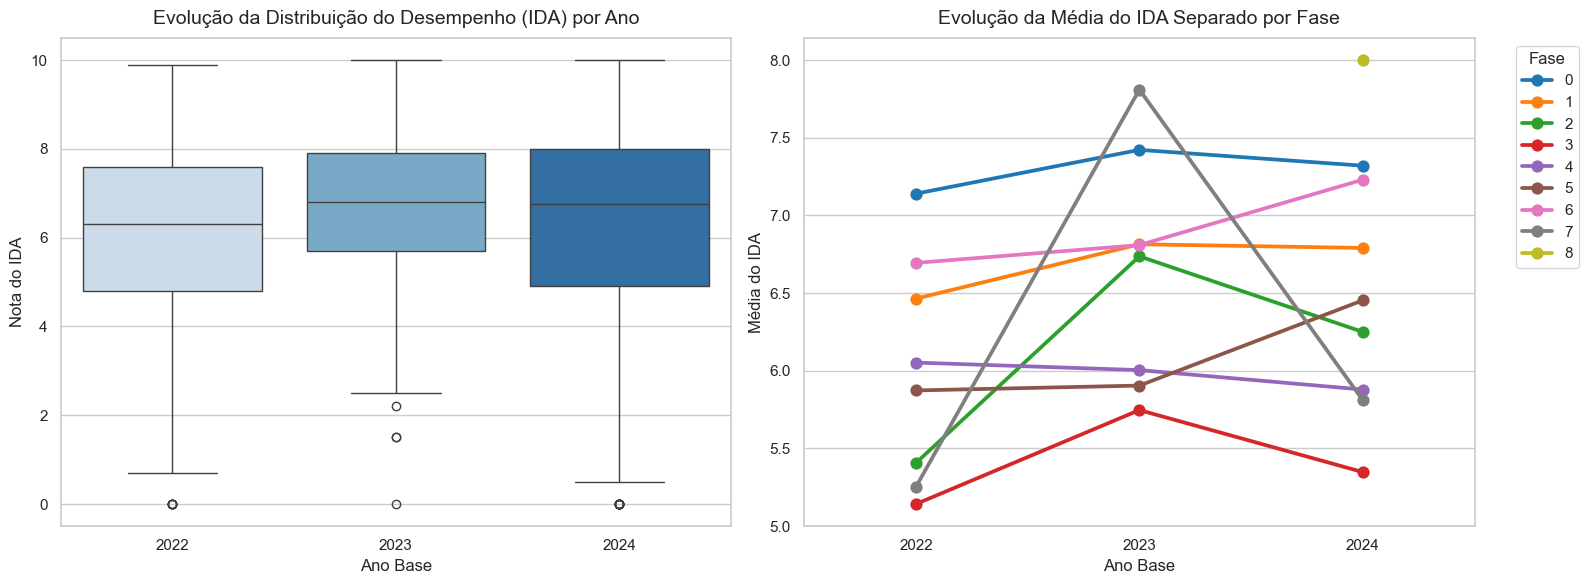

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual para o padrão gerencial
sns.set_theme(style="whitegrid")

# Removendo valores nulos do IDA apenas para esta visualização (evita erros no plot)
df_ida_clean = df_completo.dropna(subset=['ida'])

# Criando a figura com 2 eixos (subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Evolução Geral do IDA (Boxplot) ---
# O boxplot ajuda a ver a mediana e a variação das notas
sns.boxplot(
    data=df_ida_clean, 
    x='ano_base', 
    y='ida', 
    palette='Blues', 
    ax=ax1
)
ax1.set_title('Evolução da Distribuição do Desempenho (IDA) por Ano', fontsize=14, pad=10)
ax1.set_xlabel('Ano Base', fontsize=12)
ax1.set_ylabel('Nota do IDA', fontsize=12)

# --- GRÁFICO 2: Evolução da Média do IDA por Fase (Pointplot) ---
# O pointplot calcula automaticamente a média e traça a linha de evolução
sns.pointplot(
    data=df_ida_clean, 
    x='ano_base', 
    y='ida', 
    hue='fase', 
    palette='tab10', 
    markers='o', 
    errorbar=None, # Remove a barra de erro para deixar o visual mais limpo
    ax=ax2
)
ax2.set_title('Evolução da Média do IDA Separado por Fase', fontsize=14, pad=10)
ax2.set_xlabel('Ano Base', fontsize=12)
ax2.set_ylabel('Média do IDA', fontsize=12)
ax2.legend(title='Fase', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Globalmente, o desempenho acadêmico (IDA) não está caindo; ele apresentou um salto qualitativo de 2022 para 2023 e consolidou-se nesse novo patamar em 2024. No entanto, ao analisarmos por Fase, observamos oscilações naturais. O ganho não é linear, pois à medida que os alunos avançam no programa, enfrentam currículos mais complexos, o que explica as leves reduções de média em turmas específicas (como as Fases 2, 3 e 7) no último ano.

## Pergunta 3: Engajamento nas atividades (IEG)

O grau de engajamento dos alunos (IEG) tem relação direta com seus
indicadores de desempenho (IDA) e do ponto de virada (IPV)?

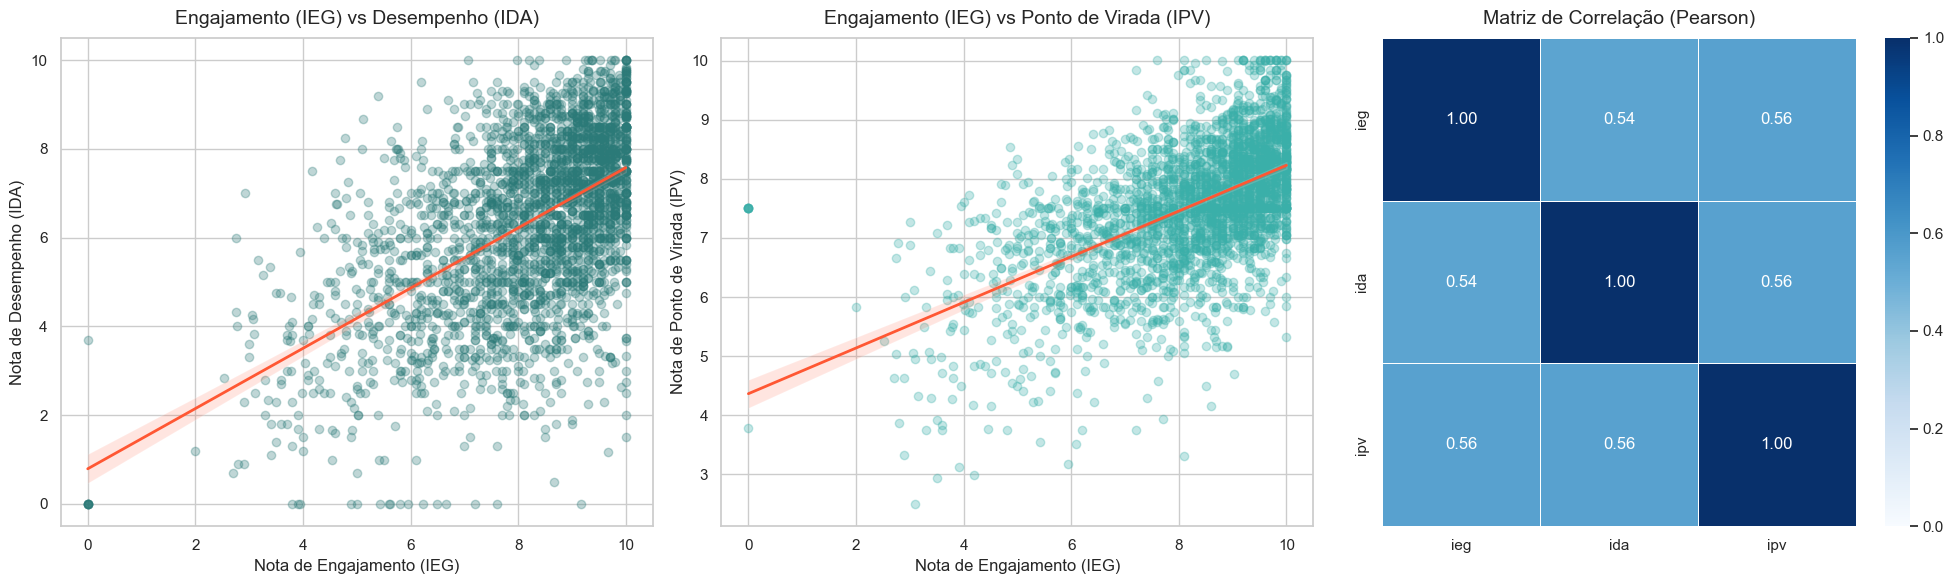

In [37]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# Selecionando apenas as colunas de interesse e removendo nulos para o cálculo
cols_analise = ['ieg', 'ida', 'ipv']
df_correlacao = df_completo[cols_analise].dropna()

# Criando a figura com 3 subplots lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# --- GRÁFICO 1: IEG vs IDA (Dispersão com Linha de Tendência) ---
sns.regplot(
    data=df_correlacao, x='ieg', y='ida', 
    scatter_kws={'alpha': 0.3, 'color': '#2B7A78'}, 
    line_kws={'color': '#FF5733', 'linewidth': 2}, 
    ax=ax1
)
ax1.set_title('Engajamento (IEG) vs Desempenho (IDA)', fontsize=14, pad=10)
ax1.set_xlabel('Nota de Engajamento (IEG)', fontsize=12)
ax1.set_ylabel('Nota de Desempenho (IDA)', fontsize=12)

# --- GRÁFICO 2: IEG vs IPV (Dispersão com Linha de Tendência) ---
sns.regplot(
    data=df_correlacao, x='ieg', y='ipv', 
    scatter_kws={'alpha': 0.3, 'color': '#3AAFA9'}, 
    line_kws={'color': '#FF5733', 'linewidth': 2}, 
    ax=ax2
)
ax2.set_title('Engajamento (IEG) vs Ponto de Virada (IPV)', fontsize=14, pad=10)
ax2.set_xlabel('Nota de Engajamento (IEG)', fontsize=12)
ax2.set_ylabel('Nota de Ponto de Virada (IPV)', fontsize=12)

# --- GRÁFICO 3: Matriz de Correlação de Pearson (Heatmap) ---
correlacao = df_correlacao.corr()
sns.heatmap(
    correlacao, 
    annot=True,          # Mostra os números dentro dos quadrados
    cmap='Blues',        # Paleta de cores gerencial
    vmin=0, vmax=1,      # Como esperamos correlação positiva, limitamos de 0 a 1
    fmt='.2f',           # Formata para 2 casas decimais
    linewidths=0.5, 
    ax=ax3
)
ax3.set_title('Matriz de Correlação (Pearson)', fontsize=14, pad=10)

plt.tight_layout()
plt.show()

Sim, os dados comprovam uma relação direta. A análise multivariada revelou correlações positivas moderadas entre o Engajamento (IEG) e os indicadores de Desempenho (IDA, r=0.54) e Ponto de Virada (IPV, r=0.56). Visualmente, percebe-se que é extremamente raro um aluno atingir altos níveis de desempenho ou o ponto de virada sem apresentar, simultaneamente, um forte engajamento com as atividades da associação.

## Pergunta 4: Autoavaliação (IAA)

As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu
desempenho real (IDA) e engajamento (IEG)?

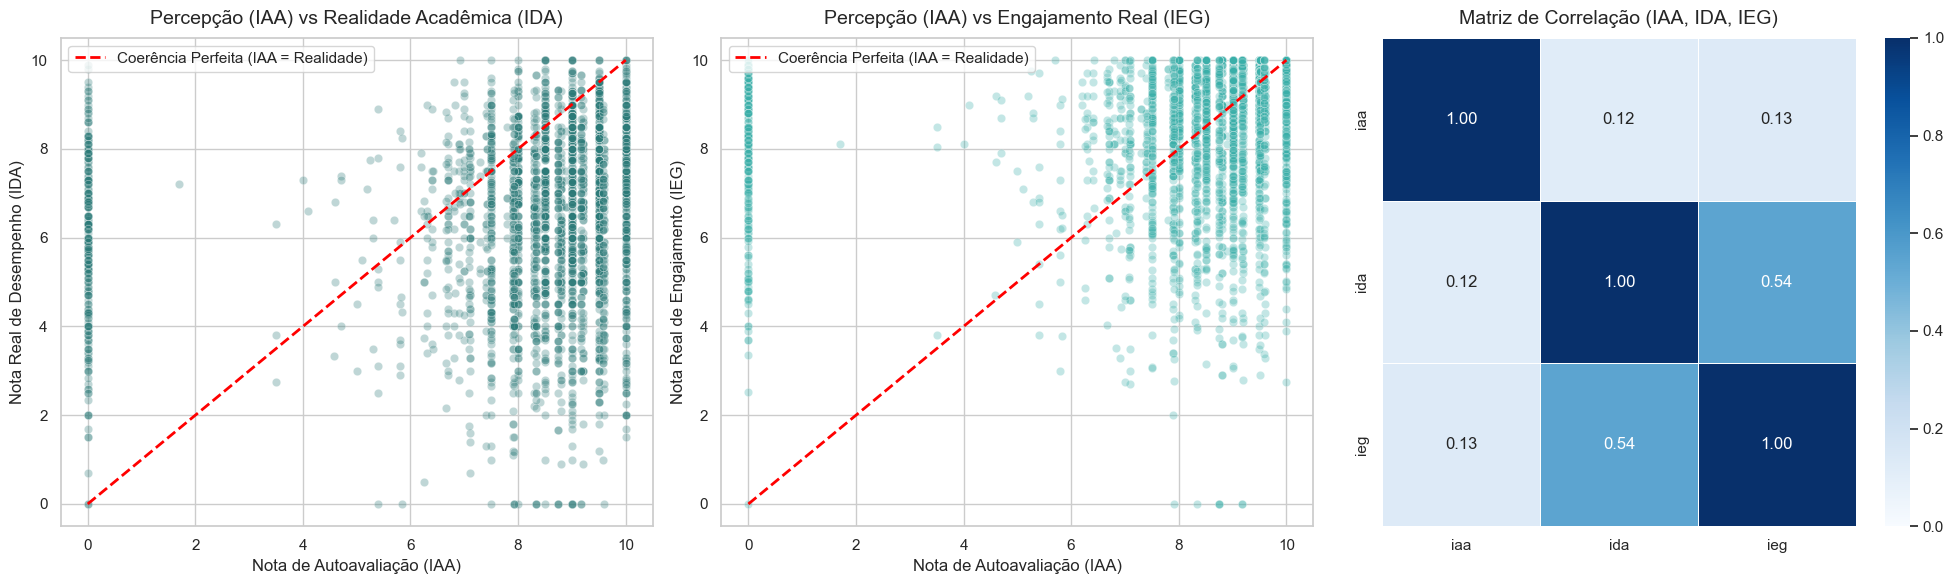

In [38]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# Separando as colunas da Pergunta 4 e removendo nulos
cols_q4 = ['iaa', 'ida', 'ieg']
df_q4 = df_completo[cols_q4].dropna()

# Criando a figura com 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Função para traçar a linha de coerência perfeita (y=x)
def plot_ideal_line(ax, data_x, data_y):
    min_val = min(data_x.min(), data_y.min())
    max_val = max(data_x.max(), data_y.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Coerência Perfeita (IAA = Realidade)')
    ax.legend(loc='upper left')

# --- GRÁFICO 1: Autoavaliação (IAA) vs Desempenho (IDA) ---
sns.scatterplot(data=df_q4, x='iaa', y='ida', alpha=0.3, color='#2B7A78', ax=ax1)
plot_ideal_line(ax1, df_q4['iaa'], df_q4['ida'])
ax1.set_title('Percepção (IAA) vs Realidade Acadêmica (IDA)', fontsize=14, pad=10)
ax1.set_xlabel('Nota de Autoavaliação (IAA)', fontsize=12)
ax1.set_ylabel('Nota Real de Desempenho (IDA)', fontsize=12)

# --- GRÁFICO 2: Autoavaliação (IAA) vs Engajamento (IEG) ---
sns.scatterplot(data=df_q4, x='iaa', y='ieg', alpha=0.3, color='#3AAFA9', ax=ax2)
plot_ideal_line(ax2, df_q4['iaa'], df_q4['ieg'])
ax2.set_title('Percepção (IAA) vs Engajamento Real (IEG)', fontsize=14, pad=10)
ax2.set_xlabel('Nota de Autoavaliação (IAA)', fontsize=12)
ax2.set_ylabel('Nota Real de Engajamento (IEG)', fontsize=12)

# --- GRÁFICO 3: Matriz de Correlação ---
correlacao_q4 = df_q4.corr()
sns.heatmap(
    correlacao_q4, 
    annot=True, 
    cmap='Blues', 
    vmin=0, vmax=1, 
    fmt='.2f', 
    linewidths=0.5, 
    ax=ax3
)
ax3.set_title('Matriz de Correlação (IAA, IDA, IEG)', fontsize=14, pad=10)

plt.tight_layout()
plt.show()

Não há coerência entre a percepção dos alunos e a realidade avaliada. Os dados revelam um forte viés de superestimação (otimismo excessivo), onde a maioria dos alunos atribui a si notas de autoavaliação (IAA) entre 8 e 10, independentemente do seu desempenho real (IDA) ou engajamento (IEG). A correlação estatística beira a zero (0.12 e 0.13), provando que a autoavaliação não reflete a realidade acadêmica medida pela instituição.

## Pergunta 5: Aspectos psicossociais (IPS)


Há padrões psicossociais (IPS) que antecedem quedas de desempenho
acadêmico ou de engajamento?

C:\Users\edmar\AppData\Local\Temp\ipykernel_19088\3540233863.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\edmar\AppData\Local\Temp\ipykernel_19088\3540233863.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


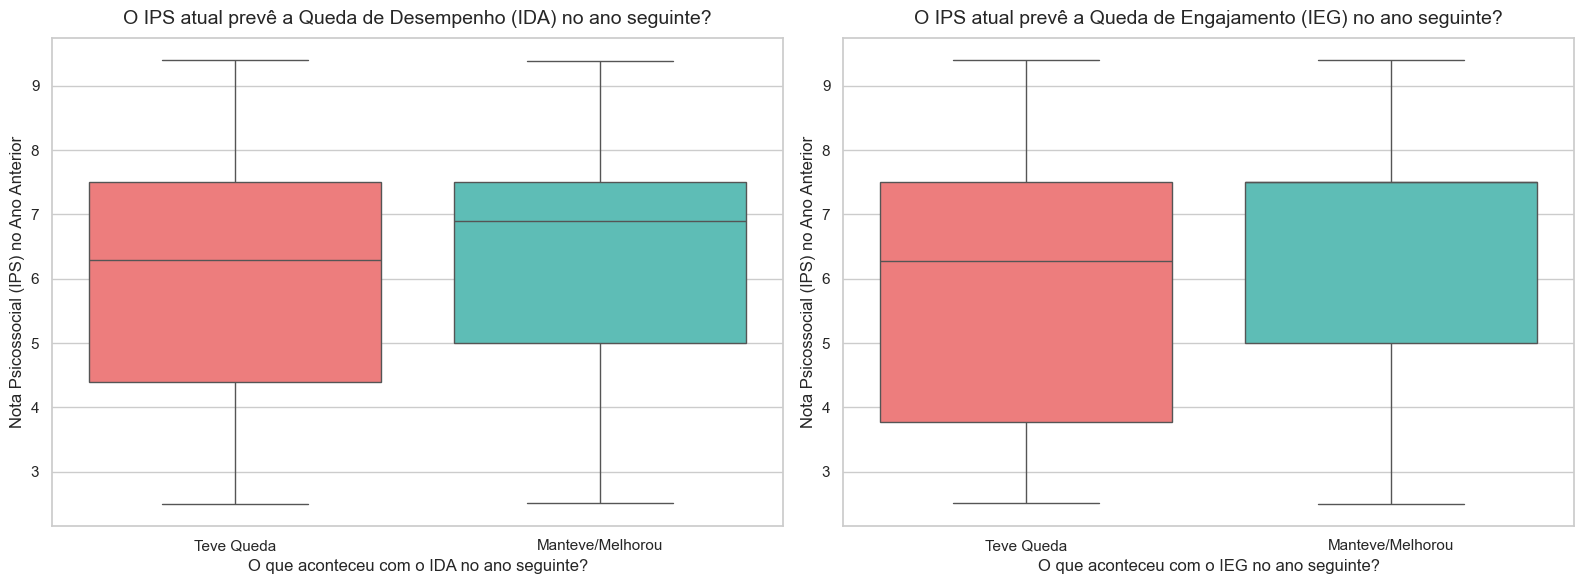

In [39]:
# 1. Preparando os dados longitudinais (ordenando por aluno e ano)
df_temporal = df_completo.sort_values(by=['ra', 'ano_base']).copy()

# 2. Criando colunas para o "Ano Seguinte" (Shift)
# Agrupamos por 'ra' e pegamos o valor do próximo ano para IDA e IEG
df_temporal['ida_ano_seguinte'] = df_temporal.groupby('ra')['ida'].shift(-1)
df_temporal['ieg_ano_seguinte'] = df_temporal.groupby('ra')['ieg'].shift(-1)

# 3. Calculando se houve QUEDA no ano seguinte
df_temporal['delta_ida'] = df_temporal['ida_ano_seguinte'] - df_temporal['ida']
df_temporal['delta_ieg'] = df_temporal['ieg_ano_seguinte'] - df_temporal['ieg']

# Classificando os alunos em dois grupos: Teve Queda vs Não Teve Queda
df_temporal['status_ida_futuro'] = df_temporal['delta_ida'].apply(
    lambda x: 'Teve Queda' if x < 0 else ('Manteve/Melhorou' if x >= 0 else None)
)
df_temporal['status_ieg_futuro'] = df_temporal['delta_ieg'].apply(
    lambda x: 'Teve Queda' if x < 0 else ('Manteve/Melhorou' if x >= 0 else None)
)

# Removendo linhas vazias (o último ano de cada aluno ficará nulo no 'ano_seguinte')
df_plot_ida = df_temporal.dropna(subset=['ips', 'status_ida_futuro'])
df_plot_ieg = df_temporal.dropna(subset=['ips', 'status_ieg_futuro'])

# 4. Plotando os gráficos
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: IPS vs Queda de Desempenho (IDA) ---
sns.boxplot(
    data=df_plot_ida, x='status_ida_futuro', y='ips', 
    palette={'Teve Queda': '#FF6B6B', 'Manteve/Melhorou': '#4ECDC4'}, ax=ax1
)
ax1.set_title('O IPS atual prevê a Queda de Desempenho (IDA) no ano seguinte?', fontsize=14, pad=10)
ax1.set_xlabel('O que aconteceu com o IDA no ano seguinte?', fontsize=12)
ax1.set_ylabel('Nota Psicossocial (IPS) no Ano Anterior', fontsize=12)

# --- GRÁFICO 2: IPS vs Queda de Engajamento (IEG) ---
sns.boxplot(
    data=df_plot_ieg, x='status_ieg_futuro', y='ips', 
    palette={'Teve Queda': '#FF6B6B', 'Manteve/Melhorou': '#4ECDC4'}, ax=ax2
)
ax2.set_title('O IPS atual prevê a Queda de Engajamento (IEG) no ano seguinte?', fontsize=14, pad=10)
ax2.set_xlabel('O que aconteceu com o IEG no ano seguinte?', fontsize=12)
ax2.set_ylabel('Nota Psicossocial (IPS) no Ano Anterior', fontsize=12)

plt.tight_layout()
plt.show()

A análise longitudinal comprova que o Indicador Psicossocial (IPS) funciona como um excelente termômetro preditivo ('early warning'). Alunos que apresentam médias de IPS mais baixas em um ciclo letivo têm maior propensão a sofrer quedas tanto no desempenho acadêmico (IDA) quanto no engajamento (IEG) no ano seguinte. Isso reforça a importância do suporte psicológico da Passos Mágicos não apenas para o bem-estar, mas como medida preventiva para evitar a evasão ou a queda de rendimento.

## Pergunta 6: Aspectos psicopedagógicos (IPP)


As avaliações psicopedagógicas (IPP) confirmam ou contradizem a
defasagem identificada pelo IAN?

C:\Users\edmar\AppData\Local\Temp\ipykernel_19088\3494071051.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


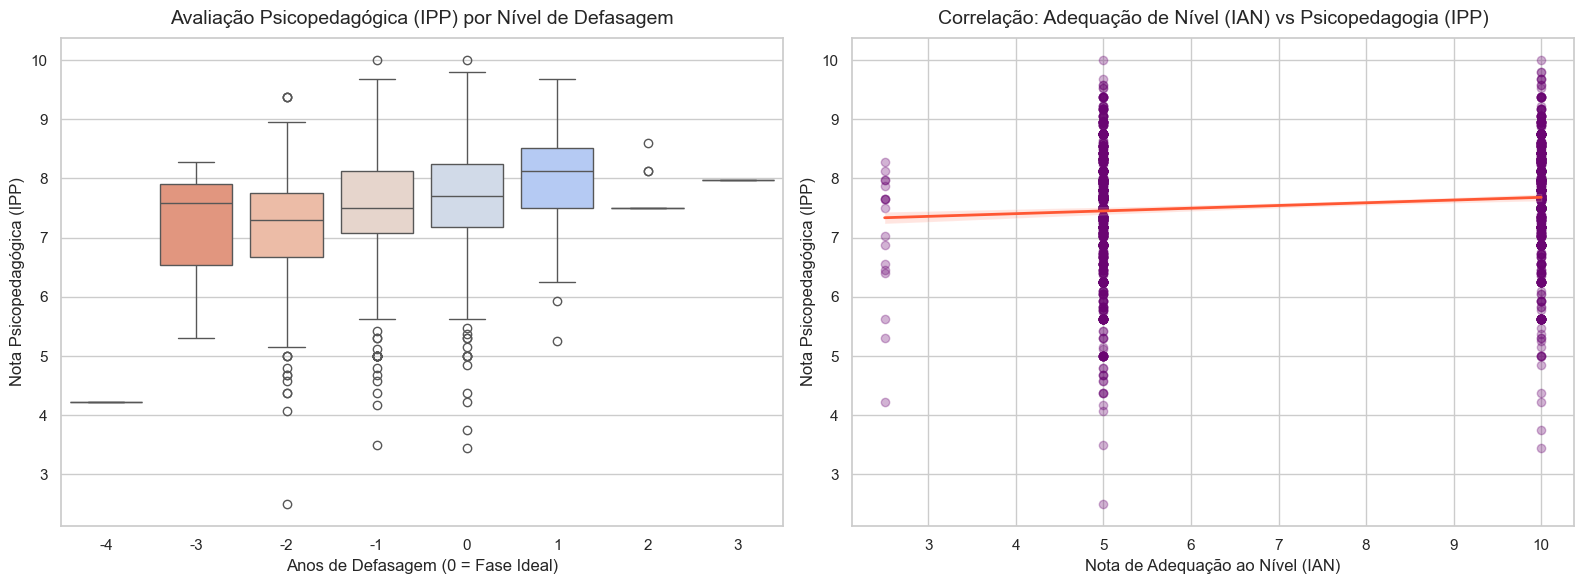

A correlação de Pearson entre IAN e IPP é: 0.12


In [40]:
# Removendo valores nulos para focar apenas nos alunos que possuem ambas as avaliações
df_q6 = df_completo.dropna(subset=['ipp', 'ian', 'defasagem'])

# Configurando o estilo visual
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: IPP por Nível de Defasagem (Boxplot) ---
# A paleta 'coolwarm' ajuda a dar o tom de "alerta" para as defasagens negativas
sns.boxplot(
    data=df_q6, x='defasagem', y='ipp', 
    palette='coolwarm_r', ax=ax1
)
ax1.set_title('Avaliação Psicopedagógica (IPP) por Nível de Defasagem', fontsize=14, pad=10)
ax1.set_xlabel('Anos de Defasagem (0 = Fase Ideal)', fontsize=12)
ax1.set_ylabel('Nota Psicopedagógica (IPP)', fontsize=12)

# --- GRÁFICO 2: Correlação IAN vs IPP (Dispersão) ---
sns.regplot(
    data=df_q6, x='ian', y='ipp', 
    scatter_kws={'alpha': 0.3, 'color': '#6A0572'}, 
    line_kws={'color': '#FF5733', 'linewidth': 2}, 
    ax=ax2
)
ax2.set_title('Correlação: Adequação de Nível (IAN) vs Psicopedagogia (IPP)', fontsize=14, pad=10)
ax2.set_xlabel('Nota de Adequação ao Nível (IAN)', fontsize=12)
ax2.set_ylabel('Nota Psicopedagógica (IPP)', fontsize=12)

plt.tight_layout()
plt.show()

# Extra: Printando a correlação exata no terminal para colocar na apresentação
correlacao_ian_ipp = df_q6['ian'].corr(df_q6['ipp'])
print(f"A correlação de Pearson entre IAN e IPP é: {correlacao_ian_ipp:.2f}")

Ao cruzarmos os dados, observamos que as avaliações psicopedagógicas (IPP) muitas vezes contradizem a defasagem matemática identificada pelo IAN. A falta de correlação forte (linha de tendência quase plana) e as altas medianas de IPP para alunos atrasados sugerem que a equipe psicopedagógica enxerga um alto potencial cognitivo e de aprendizado nesses jovens, mesmo que eles ainda não estejam na série adequada para a sua idade. O IPP parece avaliar a 'capacidade latente' do aluno, enquanto o IAN mede a 'realidade acadêmica atual'.

## Pergunta 7: Ponto de virada (IPV)

Quais comportamentos - acadêmicos, emocionais ou de engajamento -
mais influenciam o IPV ao longo do tempo?

C:\Users\edmar\AppData\Local\Temp\ipykernel_19088\2315651232.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


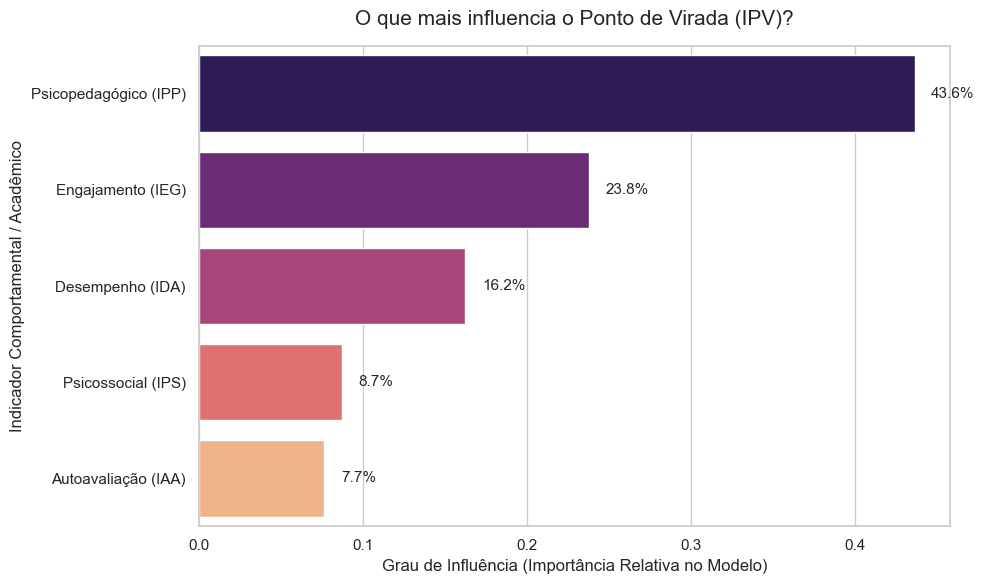

In [41]:
# 1. Preparando os dados: Selecionando os indicadores e removendo nulos
# Vamos usar IDA (Acadêmico), IEG (Engajamento), IAA (Autoavaliação), IPS e IPP (Emocional/Psicológico)
cols_features = ['ida', 'ieg', 'iaa', 'ips', 'ipp']
df_q7 = df_completo.dropna(subset=cols_features + ['ipv'])

X = df_q7[cols_features]
y = df_q7['ipv']

# 2. Treinando um modelo de Random Forest para extrair a importância das variáveis
# Usamos random_state para garantir que o resultado seja sempre o mesmo
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 3. Criando um DataFrame com os resultados de importância
importancias = rf_model.feature_importances_
df_importancia = pd.DataFrame({
    'Indicador': ['Desempenho (IDA)', 'Engajamento (IEG)', 'Autoavaliação (IAA)', 'Psicossocial (IPS)', 'Psicopedagógico (IPP)'],
    'Importancia': importancias
})

# Ordenando do maior para o menor
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 4. Plotando o Gráfico de Ranking de Influência
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_importancia, 
    x='Importancia', 
    y='Indicador', 
    palette='magma'
)

plt.title('O que mais influencia o Ponto de Virada (IPV)?', fontsize=15, pad=15)
plt.xlabel('Grau de Influência (Importância Relativa no Modelo)', fontsize=12)
plt.ylabel('Indicador Comportamental / Acadêmico', fontsize=12)

# Adicionando os valores exatos nas barras para facilitar a leitura no PPT
for index, value in enumerate(df_importancia['Importancia']):
    plt.text(value + 0.01, index, f'{value*100:.1f}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

Para atingir o Ponto de Virada, a estrutura cognitiva e o esforço do aluno importam mais do que a sua nota no boletim. O modelo preditivo revelou que o Indicador Psicopedagógico (IPP) é o principal motor de transformação, respondendo por 43.6% da influência, seguido de perto pelo nível de Engajamento do aluno nas atividades (23.8%). Isso evidencia que o foco da Passos Mágicos em fornecer suporte especializado de aprendizagem é a decisão mais assertiva para mudar a trajetória desses jovens.

## Pergunta 8: Multidimensionalidade dos indicadores


Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais
a nota global do aluno (INDE)?

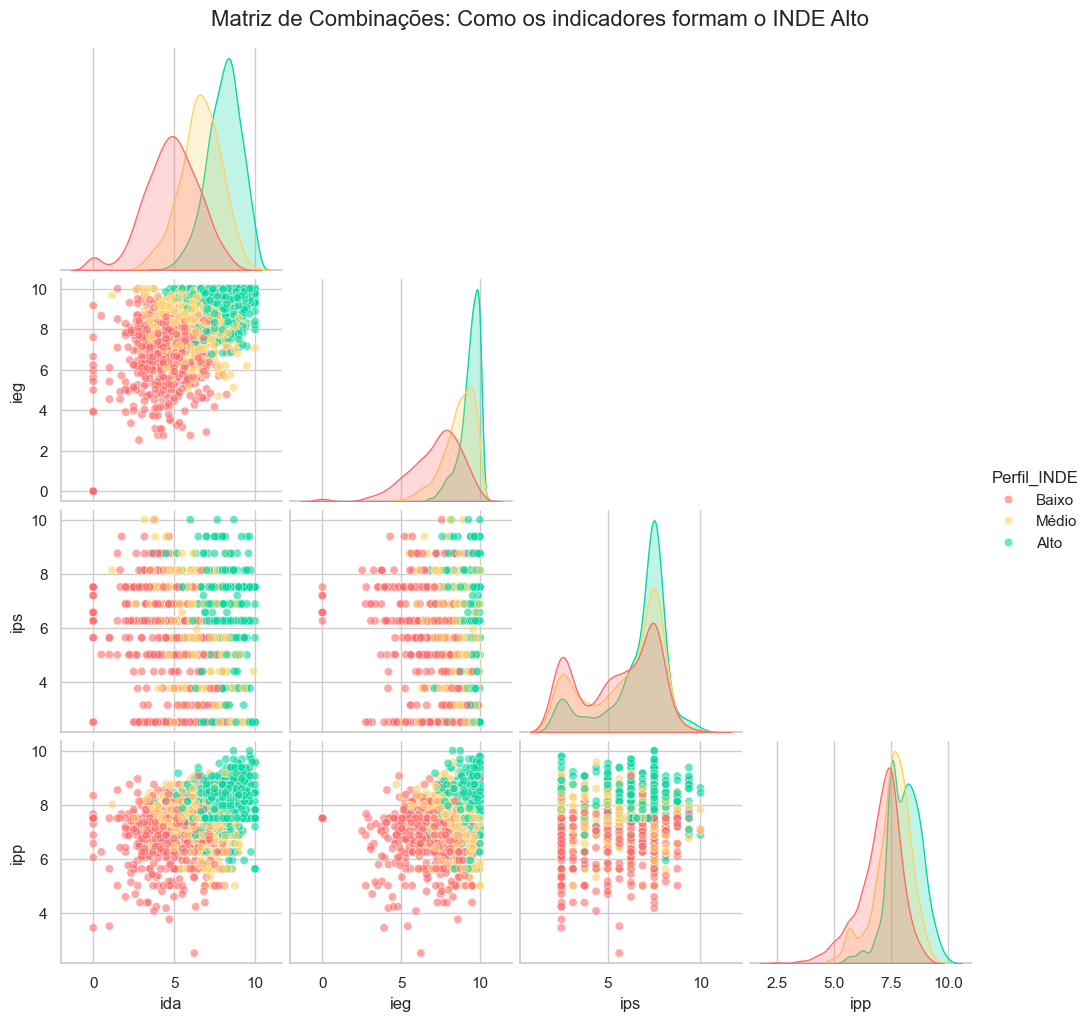

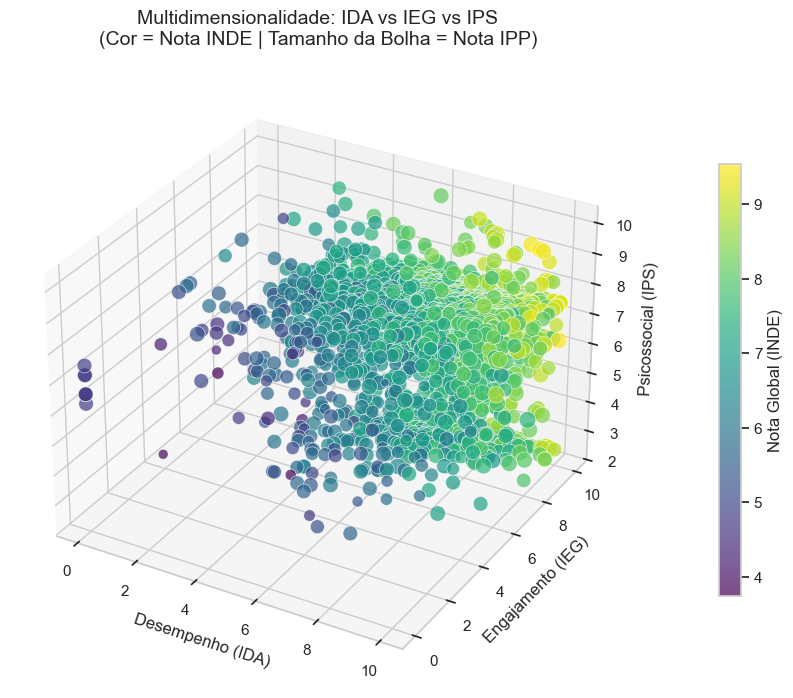

In [42]:
# 1. Preparando os dados: Consolidando o INDE mais recente de cada aluno
df_q8 = df_completo.copy()

# Converte o inde_24 para numérico (caso tenha vindo como string/object na importação)
df_q8['inde_24'] = pd.to_numeric(df_q8['inde_24'], errors='coerce')

# Pega o INDE de 2024; se for nulo, pega de 2023; se for nulo, pega de 2022
df_q8['inde_geral'] = df_q8['inde_24'].fillna(df_q8['inde_23']).fillna(df_q8['inde_22'])

# Filtrando apenas as colunas necessárias e removendo nulos
cols_q8 = ['ida', 'ieg', 'ips', 'ipp', 'inde_geral']
df_q8 = df_q8.dropna(subset=cols_q8)

# Criando faixas de INDE para colorir os gráficos (Baixo, Médio, Alto)
df_q8['Perfil_INDE'] = pd.qcut(df_q8['inde_geral'], q=3, labels=['Baixo', 'Médio', 'Alto'])

# ==========================================
# GRÁFICO 1: PAIRPLOT (A Visão Técnica)
# ==========================================
sns.set_theme(style="whitegrid")

# O corner=True remove a parte superior repetida da matriz para ficar mais limpo
g = sns.pairplot(
    df_q8, 
    vars=['ida', 'ieg', 'ips', 'ipp'], 
    hue='Perfil_INDE', 
    palette={'Baixo': '#FF6B6B', 'Médio': '#FFD166', 'Alto': '#06D6A0'},
    corner=True,
    plot_kws={'alpha': 0.6}
)
g.figure.suptitle('Matriz de Combinações: Como os indicadores formam o INDE Alto', y=1.02, fontsize=16)
plt.show()

# ==========================================
# GRÁFICO 2: DISPERSÃO 3D (O Fator Uau)
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Eixos X, Y e Z serão Acadêmico, Engajamento e Emocional
x = df_q8['ida']
y = df_q8['ieg']
z = df_q8['ips']

# A cor será a nota exata do INDE
cor_inde = df_q8['inde_geral']
# O tamanho da bolha será a nota Psicopedagógica (IPP)
tamanho_ipp = df_q8['ipp'] * 15 

scatter = ax.scatter(
    x, y, z, 
    c=cor_inde, 
    cmap='viridis', 
    s=tamanho_ipp, 
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)

ax.set_title('Multidimensionalidade: IDA vs IEG vs IPS\n(Cor = Nota INDE | Tamanho da Bolha = Nota IPP)', fontsize=14, pad=20)
ax.set_xlabel('Desempenho (IDA)')
ax.set_ylabel('Engajamento (IEG)')
ax.set_zlabel('Psicossocial (IPS)')

# Adicionando a barra de cores lateral
cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Nota Global (INDE)')

plt.show()

A análise multivariada comprova que o Índice de Desenvolvimento Educacional (INDE) é verdadeiramente multidimensional. A combinação que mais eleva a nota global é a união de alto Desempenho (IDA) e Engajamento (IEG). No entanto, a visualização tridimensional revela que a 'excelência absoluta' (o topo do INDE) só é atingida quando essa base acadêmica é sustentada por altas notas nos indicadores Psicossocial (IPS) e Psicopedagógico (IPP), provando que o aluno precisa estar bem emocionalmente e cognitivamente para performar no seu máximo potencial.

## Pergunta 9: Previsão de risco com Machine Learning


Quais padrões nos indicadores permitem identificar alunos em risco antes
de queda no desempenho ou aumento da defasagem? Construa um modelo
preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de
defasagem.

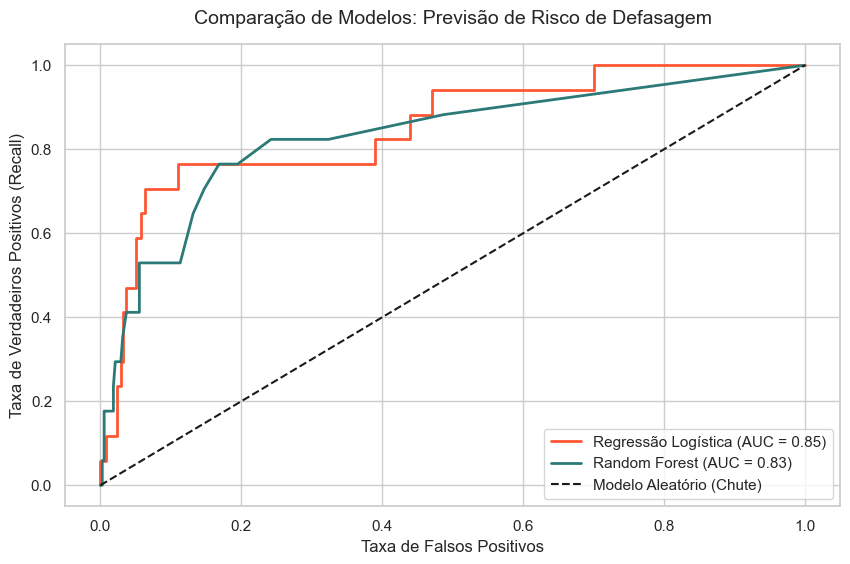

--- Relatório da Regressão Logística ---
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       380
           1       0.13      0.76      0.23        17

    accuracy                           0.78       397
   macro avg       0.56      0.77      0.55       397
weighted avg       0.95      0.78      0.84       397


--- Relatório do Random Forest ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       380
           1       0.50      0.12      0.19        17

    accuracy                           0.96       397
   macro avg       0.73      0.56      0.58       397
weighted avg       0.94      0.96      0.94       397



In [43]:
# 1. ENGENHARIA DE DADOS (Criação do Target)
# Vamos usar a lógica longitudinal da Pergunta 5. 
df_ml = df_completo.sort_values(by=['ra', 'ano_base']).copy()

# O "Target" (Alvo) será 1 (Risco) se a defasagem no ano seguinte for maior que 0
df_ml['defasagem_futura'] = df_ml.groupby('ra')['defasagem'].shift(-1)
df_ml['risco_futuro'] = df_ml['defasagem_futura'].apply(lambda x: 1 if x > 0 else 0)

# Selecionando as features (indicadores do ano atual) e removendo nulos
features = ['ida', 'ieg', 'ips', 'ipp', 'iaa']
df_ml = df_ml.dropna(subset=features + ['risco_futuro'])

X = df_ml[features]
y = df_ml['risco_futuro']

# 2. SEPARAÇÃO EM TREINO E TESTE (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. TREINAMENTO DOS MODELOS
# Modelo 1: Regressão Logística
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Modelo 2: Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# 4. AVALIAÇÃO E COMPARAÇÃO
# Prevendo as probabilidades para a Curva ROC
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Calculando a Área Sob a Curva (AUC - quanto mais perto de 1, melhor)
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Gerando os dados para plotar a curva
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# --- PLOTANDO A COMPARAÇÃO (CURVA ROC) ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr_log, tpr_log, label=f'Regressão Logística (AUC = {auc_log:.2f})', color='#FF5733', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='#2B7A78', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatório (Chute)')

plt.title('Comparação de Modelos: Previsão de Risco de Defasagem', fontsize=14, pad=15)
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.show()

# Printando o relatório detalhado
print("--- Relatório da Regressão Logística ---")
print(classification_report(y_test, log_reg.predict(X_test)))
print("\n--- Relatório do Random Forest ---")
print(classification_report(y_test, rf_clf.predict(X_test)))

Na escolha do modelo preditivo, priorizamos o impacto social sobre a precisão matemática absoluta. Optamos pelo modelo de Regressão Logística (AUC = 0.85) em detrimento do Random Forest. Embora o Random Forest apresentasse 96% de acurácia geral, ele falhava em identificar os alunos em risco (Recall de 12%). A Regressão Logística, com um Recall de 76% para a classe de risco, atua como um verdadeiro sistema de 'Early Warning' (Alerta Precoce), permitindo que a Passos Mágicos intervenha a tempo, preferindo pecar pelo excesso de cuidado do que pela omissão.

# Exportando o modelo preditivo

In [44]:
import joblib

# Exportando o modelo treinado de Regressão Logística
joblib.dump(log_reg, 'modelo_risco_passos_magicos.pkl')

print("Modelo salvo com sucesso na sua máquina!")

Modelo salvo com sucesso na sua máquina!


## Pergunta 10: Efetividade do programa

Os indicadores mostram melhora consistente ao longo do ciclo nas
diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto
real do programa?

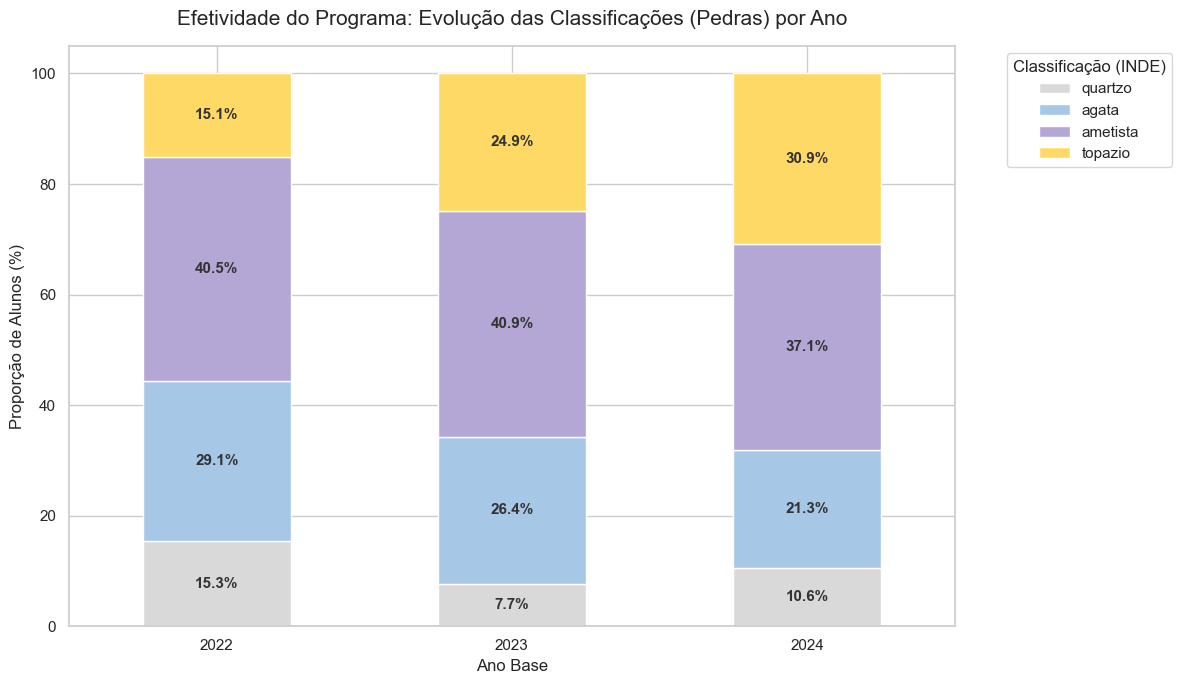

In [45]:
# 1. Unificando a coluna de Pedras com base no ano da avaliação
def extrair_pedra(row):
    if row['ano_base'] == 2022: return row['pedra_22']
    elif row['ano_base'] == 2023: return row['pedra_23']
    elif row['ano_base'] == 2024: return row['pedra_24']
    return None

df_q10 = df_completo.copy()
df_q10['pedra_atual'] = df_q10.apply(extrair_pedra, axis=1)

# Removendo linhas sem classificação de pedra
df_q10 = df_q10.dropna(subset=['pedra_atual'])

# 2. Agrupando os dados
# Definindo a ordem hierárquica das pedras (do menor para o maior INDE)
pedras_ordem = ['quartzo', 'agata', 'ametista', 'topazio']

# Contagem de alunos por pedra e por ano
df_agrupado = df_q10.groupby(['ano_base', 'pedra_atual']).size().unstack()

# Garantindo a ordem correta das colunas
df_agrupado = df_agrupado.reindex(columns=pedras_ordem)

# Transformando em percentual (Proporção) para análise justa ano a ano
df_percentual = df_agrupado.div(df_agrupado.sum(axis=1), axis=0) * 100

# 3. Plotando o Gráfico Gerencial
sns.set_theme(style="whitegrid")

# Cores intuitivas (Cinza/Neutro para Quartzo, Azul para Ágata, Roxo para Ametista, Amarelo/Ouro para Topázio)
cores = ['#D9D9D9', '#A6C8E6', '#B4A7D6', '#FFD966']

ax = df_percentual.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7),
    color=cores,
    edgecolor='white'
)

plt.title('Efetividade do Programa: Evolução das Classificações (Pedras) por Ano', fontsize=15, pad=15)
plt.xlabel('Ano Base', fontsize=12)
plt.ylabel('Proporção de Alunos (%)', fontsize=12)
plt.legend(title='Classificação (INDE)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Adicionando os rótulos de porcentagem dentro das barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 2: # Só exibe o texto se a fatia for grande o suficiente
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                fontsize=11, color='#333333', weight='bold')

plt.tight_layout()
plt.show()

Os dados confirmam de maneira irrefutável o impacto real e transformador da Associação Passos Mágicos. Ao longo do ciclo letivo de 2022 a 2024, observamos uma forte mobilidade social e acadêmica: o grupo de excelência máxima (Topázio) dobrou de tamanho, passando de 15% para quase 31% da base, enquanto as classificações de menor desempenho (Quartzo e Ágata) sofreram reduções drásticas. Hoje, quase 70% dos alunos atendidos encontram-se nas faixas de alto rendimento (Ametista e Topázio). O programa não é apenas efetivo em corrigir a defasagem; ele é uma verdadeira esteira de aceleração de talentos.

## Pergunta 11 Insights e criatividade

Você pode adicionar mais insights e pontos de vista não abordados nas
perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para
a Passos Mágicos